---
title: "Competition Organizers"
subtitle: "Ranking participants and reporting significance with CompStats"
---

This page is aimed at people organizing a competition rather than at a single `sklearn` user: given a gold standard and the predictions submitted by several participants, `CompStats` produces a ranking, confidence intervals for every submission, and p-values for the difference against the best submission -- all from the same paired bootstrap distribution, so the comparisons stay valid even when many participants are involved.

## Dataset

The example uses the gold labels of [INGEOTEC/Delitos](https://github.com/INGEOTEC/Delitos), a corpus of tweets labeled as mentioning a crime (`1`) or not (`0`). Because the tweets' text cannot be redistributed under Twitter/X's terms of service, the published corpus only contains each tweet's id and label; the following cell downloads the test partition and keeps the labels, which play the role of the gold standard an organizer would hold out from the competition's participants.

In [1]:
import json
import urllib.request
import numpy as np

url = ("https://raw.githubusercontent.com/INGEOTEC/Delitos/main/"
       "corpus/delitos_test.json")
with urllib.request.urlopen(url) as fh:
    lines = fh.read().decode('utf-8').splitlines()
y_gold = np.array([json.loads(line)['label'] for line in lines])
y_gold.shape, y_gold.mean()

((360,), np.float64(0.2111111111111111))

## Simulated submissions

With only the labels available (no text to train a real classifier on), four submissions are simulated by flipping the gold label with a different probability per team -- higher skill means fewer flipped labels. This mirrors the kind of table an organizer receives: one column per participant, aligned with the same gold standard, plus a majority-class baseline that many competitions include for reference.

In [2]:
def simulate_submission(y_true, skill, seed):
    """A synthetic participant that mislabels with probability (1 - skill)"""
    rng = np.random.default_rng(seed)
    flip = rng.random(y_true.shape[0]) > skill
    y_pred = y_true.copy()
    y_pred[flip] = 1 - y_pred[flip]
    return y_pred

submissions = {
    'Team Alpha': simulate_submission(y_gold, skill=0.95, seed=0),
    'Team Beta': simulate_submission(y_gold, skill=0.90, seed=1),
    'Team Gamma': simulate_submission(y_gold, skill=0.85, seed=2),
    'Majority baseline': np.zeros_like(y_gold),
}

## Ranking the submissions

`CompStats.metrics.f1_score` follows the `sklearn.metrics` convention -- `(y_true, y_pred)` -- and returns a `Perf` instance instead of a bare float. Passing every submission's predictions, one call per team, builds the comparison and sorts it by performance.

In [3]:
from CompStats.metrics import f1_score

leaderboard = None
for team, y_pred in submissions.items():
    if leaderboard is None:
        leaderboard = f1_score(y_gold, y_pred, name=team, pos_label=1)
    else:
        leaderboard(y_pred, name=team)
leaderboard

<Perf(func=f1_score)>
Statistic with its standard error (se)
statistic (se)
0.8554 (0.0292) <= Team Alpha
0.8140 (0.0315) <= Team Beta
0.7380 (0.0366) <= Team Gamma
0.0000 (0.0000) <= Majority baseline

## Confidence intervals

`Perf.ci` reports the percentile bootstrap confidence interval for every submission's F1 score, so the ranking above can be reported together with a measure of its uncertainty.

In [4]:
leaderboard.ci

{'Team Alpha': (np.float64(0.7923241852487136),
  np.float64(0.9102991944764096)),
 'Team Gamma': (np.float64(0.6607642357642357),
  np.float64(0.8012209302325581)),
 'Majority baseline': (np.float64(0.0), np.float64(0.0)),
 'Team Beta': (np.float64(0.750719696969697), np.float64(0.8739589221782551))}

## Significance against the best submission

`Perf.difference` compares every other submission against the best one -- `Team Alpha` here -- using the paired bootstrap distribution of the differences, and `Difference.p_value` turns that distribution into a p-value per submission. A low p-value indicates the gap from the best submission is unlikely to be due to chance, while a submission with a high p-value is statistically indistinguishable from the winner.

In [5]:
comparison = leaderboard.difference()
comparison

<Difference>
difference p-values  w.r.t Team Alpha
0.0000 <= Majority baseline
0.0060 <= Team Gamma
0.1380 <= Team Beta

In [6]:
comparison.p_value()

{'Majority baseline': np.float64(0.0),
 'Team Gamma': np.float64(0.006),
 'Team Beta': np.float64(0.138)}

## Visualizing the comparison

`Perf.plot` and `Difference.plot` render the leaderboard and the pairwise comparison, respectively, with confidence intervals computed from the same bootstrap distribution.

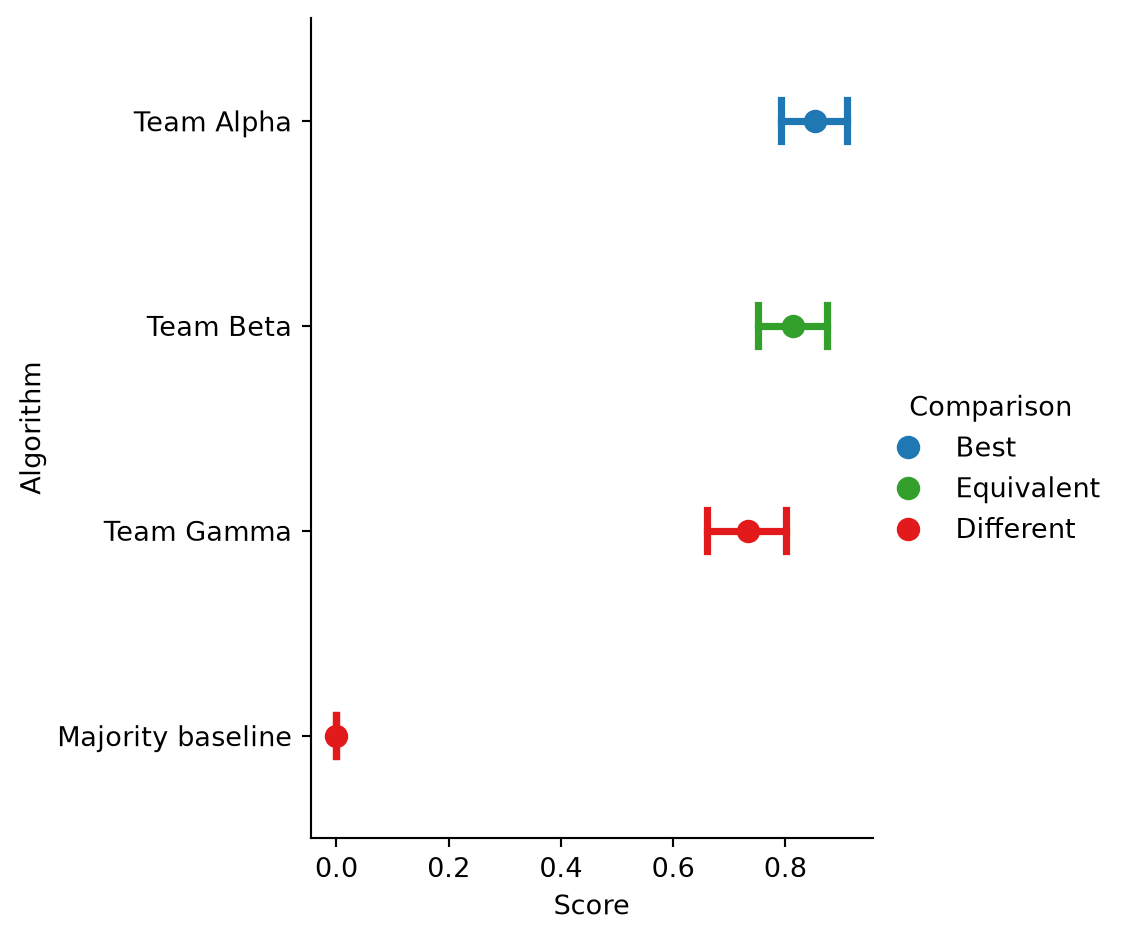

In [7]:
leaderboard.plot()

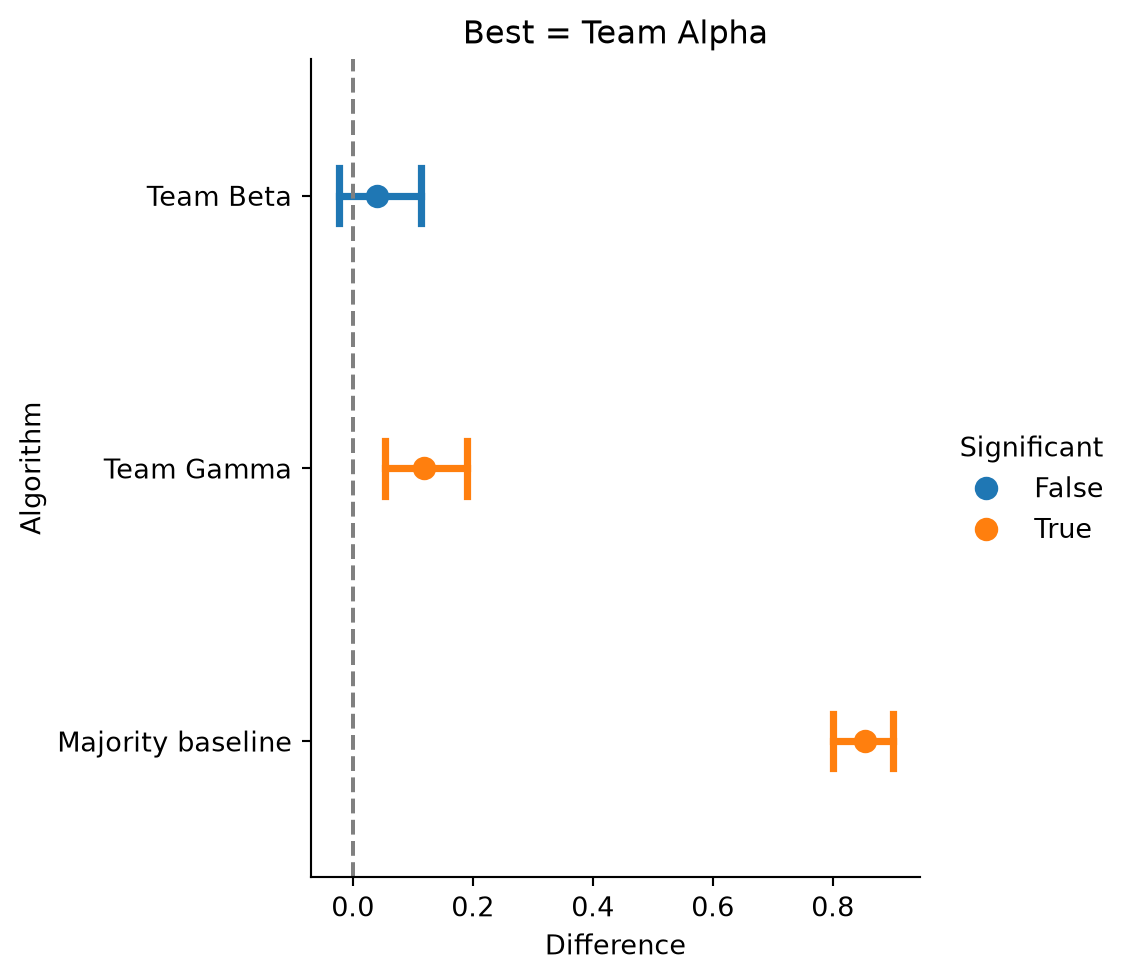

In [8]:
comparison.plot()

[scikit-learn Users](sklearn_users.ipynb) shows the same workflow when comparing a handful of estimators against a single gold standard, and [Multiple Testing](multiple_testing.ipynb) shows how to combine several measures in a single `Perf` and correct their p-values.